In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
%matplotlib widget
from IPython.display import display

import LightPlotsFunctions

In [2]:
with uproot.open("LightValidation.root") as file:    
    tree = file['events']
    print(tree.keys())
    branches = tree.arrays(['opHitPositionsX', 'opHitPositionsY', 'opHitPositionsZ', 'opHitPeakTimes', 'opHitWidths', 'opHitPEs', 'opHitStartTimes',
                            'mcpPdgs', 'mcpIsMichel', 'mcpTimes', 'mcpEnergies',
                            'mcpTrajPointX', 'mcpTrajPointY', 'mcpTrajPointZ', 'mcpTrajPointT'], library="ak")

['opHitPEs', 'opHitPeakTimes', 'opHitStartTimes', 'opHitWidths', 'opHitPositionsX', 'opHitPositionsY', 'opHitPositionsZ', 'opHitChannels', 'mcpTimes', 'mcpEnergies', 'mcpPdgs', 'mcpIsMichel', 'mcpTrajPointX', 'mcpTrajPointY', 'mcpTrajPointZ', 'mcpTrajPointT']


<div class="alert alert-block alert-info" style="font-size: 18px;">
  Pick an event to look at
</div>

In [3]:
EVENT_INDEX = 0

In [4]:
# Flatten...
Y = np.asarray(branches['opHitPositionsY'][EVENT_INDEX]).flatten()
Z = np.asarray(branches['opHitPositionsZ'][EVENT_INDEX]).flatten()
PE = np.asarray(branches['opHitPEs'][EVENT_INDEX]).flatten()
START_TIME = np.asarray(branches['opHitStartTimes'][EVENT_INDEX]).flatten()
WIDTH= np.asarray(branches['opHitWidths'][EVENT_INDEX]).flatten()
PEAK_TIME = np.asarray(branches['opHitPeakTimes'][EVENT_INDEX]).flatten()

MCX=np.asarray(branches['mcpTrajPointX'][EVENT_INDEX]).flatten()
MCY=np.asarray(branches['mcpTrajPointY'][EVENT_INDEX]).flatten()
MCZ=np.asarray(branches['mcpTrajPointZ'][EVENT_INDEX]).flatten()
MCT=np.asarray(branches['mcpTrajPointT'][EVENT_INDEX]).flatten()*0.001


MC_TIME=np.asarray(branches['mcpTimes'][EVENT_INDEX]).flatten()*0.001
MC_PDG=np.asarray(branches['mcpPdgs'][EVENT_INDEX]).flatten()
MC_IS_MICHEL=np.asarray(branches['mcpIsMichel'][EVENT_INDEX]).flatten()
MC_E=np.asarray(branches['mcpEnergies'][EVENT_INDEX]).flatten()

MC_MASK = (MC_E > 1e-2) & (~np.char.startswith(MC_PDG.astype(str), '1000'))
MC_TIME=MC_TIME[MC_MASK]
MC_PDG=MC_PDG[MC_MASK]
MC_IS_MICHEL=MC_IS_MICHEL[MC_MASK]
MC_E=MC_E[MC_MASK]

# Create list of actual PMT positions
pmt_positions = np.unique(np.stack((Y, Z), axis=1), axis=0)

In [11]:
-591.5687 --529.29834 

-62.27035999999998

In [10]:
print(pmt_positions)

[[-591.5687     35.11875 ]
 [-591.5687     83.91875 ]
 [-591.5687    146.71875 ]
 [-591.5687    195.51875 ]
 [-591.5687    267.50876 ]
 [-591.5687    316.30875 ]
 [-591.5687    379.10876 ]
 [-591.5687    427.90875 ]
 [-591.5687    499.89874 ]
 [-591.5687    548.6987  ]
 [-591.5687    611.4988  ]
 [-591.5687    660.29877 ]
 [-591.5687    732.28876 ]
 [-591.5687    781.08875 ]
 [-591.5687    843.88873 ]
 [-591.5687    892.6887  ]
 [-591.5687    964.6788  ]
 [-591.5687   1013.47876 ]
 [-591.5687   1076.2788  ]
 [-591.5687   1125.0787  ]
 [-591.5687   1197.0687  ]
 [-591.5687   1245.8688  ]
 [-591.5687   1308.6687  ]
 [-591.5687   1357.4688  ]
 [-529.29834    35.11875 ]
 [-529.29834    83.91875 ]
 [-529.29834   146.71875 ]
 [-529.29834   195.51875 ]
 [-529.29834   267.50876 ]
 [-529.29834   316.30875 ]
 [-529.29834   379.10876 ]
 [-529.29834   427.90875 ]
 [-529.29834   499.89874 ]
 [-529.29834   548.6987  ]
 [-529.29834   611.4988  ]
 [-529.29834   660.29877 ]
 [-529.29834   732.28876 ]
 

In [5]:
print('MCParticles in Event:', MC_PDG)
print('Creation time:', MC_TIME)
print('Is michel electron:', MC_IS_MICHEL)
print(MC_E > 1e-2)

MCParticles in Event: [-13 -14 -11]
Creation time: [0.        3.8636706 3.8636706]
Is michel electron: [0 0 0]
[ True  True  True]


<div class="alert alert-block alert-info" style="font-size: 18px;">
  Plot 1: Intesity as a function of time (on all PMTs) assigning all intensity to the peak time 
</div>

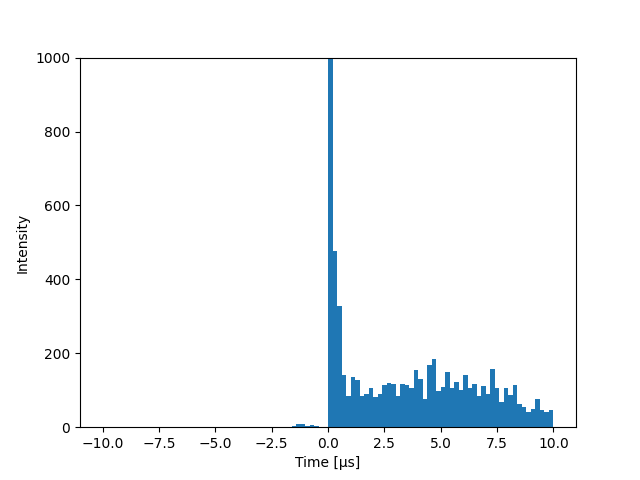

In [6]:
LightPlotsFunctions.plot1(PEAK_TIME, PE)

<div class="alert alert-block alert-info" style="font-size: 18px;">
  Plot 2: Intesity as a function of time (on all PMTs), distributing the intensity via exponential decay, seeded on the peak time
</div>

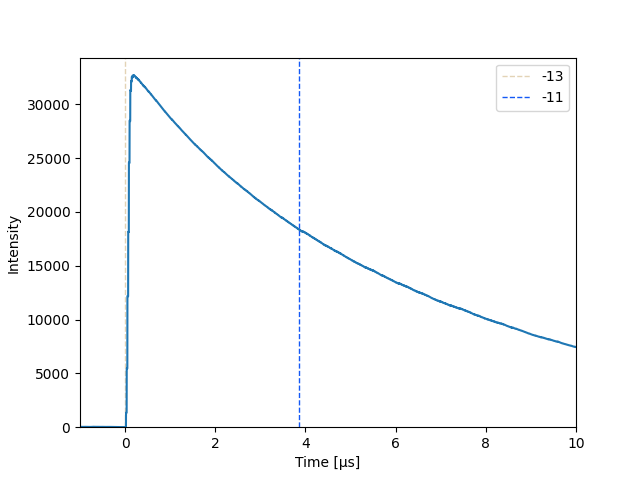

In [7]:
LightPlotsFunctions.plot2(PEAK_TIME, WIDTH, PE, MC_TIME, MC_PDG, MC_IS_MICHEL)

<div class="alert alert-block alert-info" style="font-size: 18px;">
  Plot 3: Intensity on PMT at a specified time and within a specified time window
</div>

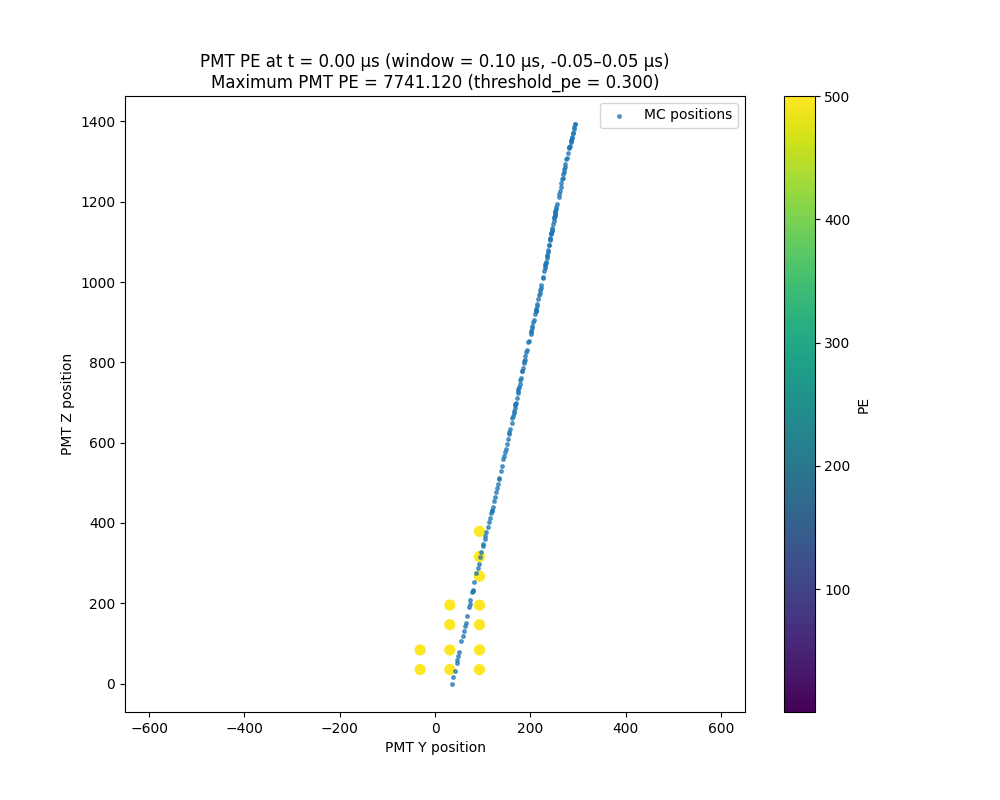

In [8]:
LightPlotsFunctions.plot3(Y, Z, PE, PEAK_TIME, MCX, MCY, MCZ, MCT, t_min=0.0, t_max=10.0, time_window=0.1, 








                          

<div class="alert alert-block alert-info" style="font-size: 18px;">
  Plot 4: Intensity on PMT at a specified time and within a specified time window, with pe weighted pca fit overlayed
</div>

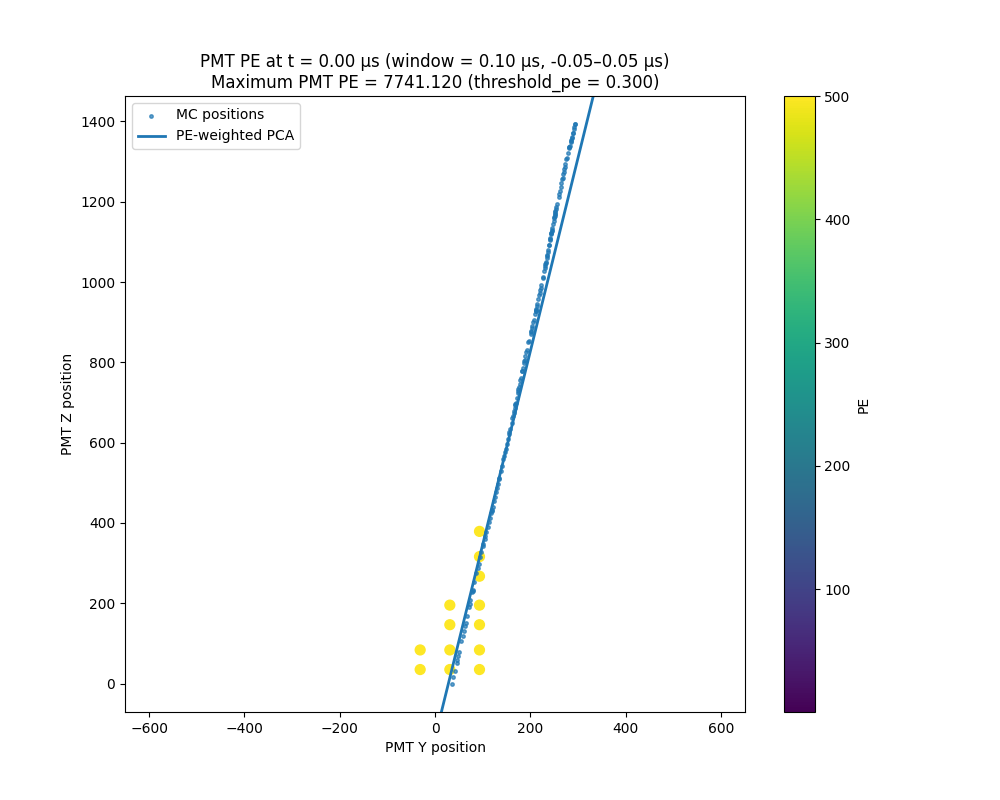

In [9]:
LightPlotsFunctions.plot4(Y, Z, PE, PEAK_TIME, MCX, MCY, MCZ, MCT, t_min=0.0, t_max=10.0, time_window=0.1, threshold_pe=0.3, z_max=500.0)